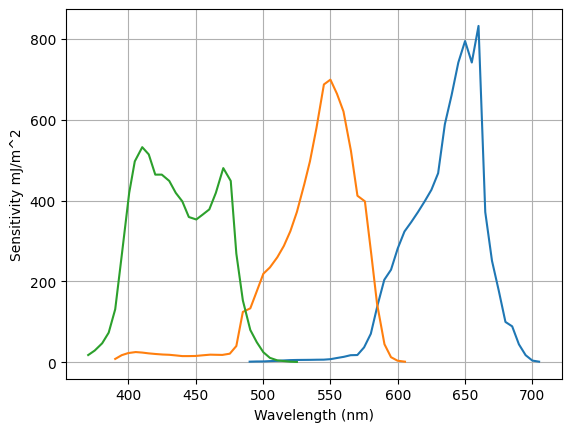

44188.07122743963
42479.03968675643
40602.0228714817
44188.07122743963
42479.03968675643
40602.0228714817
44188.07122743963
42479.03968675643
40602.0228714817
white ▉
             x         y
0   355.180723  0.983929
1   360.361446  0.986402
2   365.143652  0.990110
3   370.324374  0.988874
4   375.106580  0.983929
..         ...       ...
81  765.254866  0.997528
82  765.254866  0.997528
83  770.037071  0.997528
84  774.819277  0.998764
85  780.000000  0.998764

[86 rows x 2 columns]


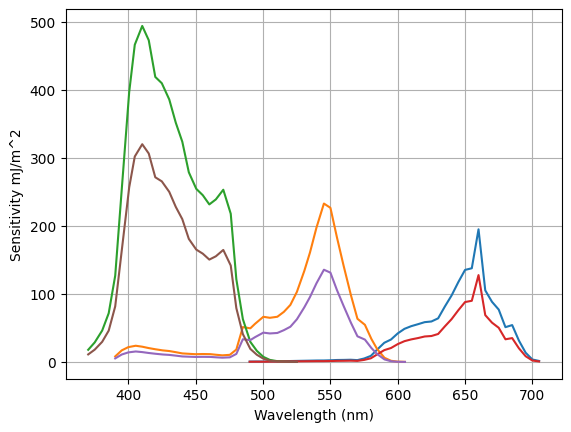

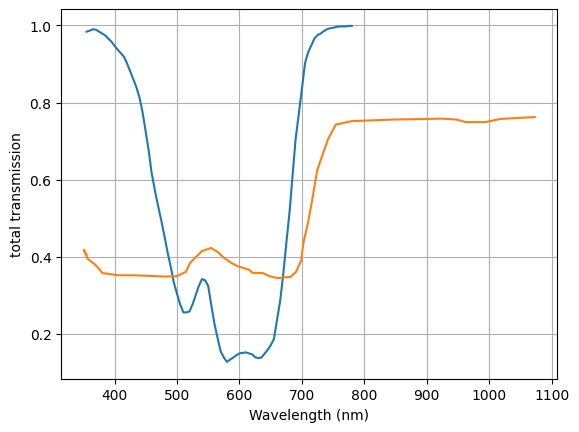

In [26]:
"""spectral analysis(colormaster)"""
"""By Matija Breljak"""
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from colorist import ColorRGB
x=[490, 495, 500, 505, 510, 515, 520 , 525, 530, 535, 540, 545, 550, 555, 560,565, 570, 575,580,585,590,595,600,605,610,615,620,625,630,635,640,645,650,655,660,665, 670, 675, 680,685, 690, 695, 700, 705]
y=[0.25,0.65,1.25,1.65,1.95,2,2.25,2.4,2.57,2.92,2.87,2.9,2.87,2.82,2.77,2.67,2.63,2.6,2.57,2.54,2.51,2.45,2.36,2.31,2.15,1.85,1.57,1.26,1.25,1.14,1.04,0.9,0.83,0.82,0.8,0.79,0.778,0.75,0.68,0.57,0.5,0.37,0.35,0.25]
y.reverse()
yt = [10**i  for i in y]
Magenta = pd.read_csv("/content/sample_data/Kodak-Portra-800-MagentaForming-data.csv")
Yellow = pd.read_csv("/content/sample_data/Kodak-Portra-800-YellowForming-data.csv")
M=np.array(Magenta.iloc[:, 0]), [10**i  for i in np.array(Magenta.iloc[:, 1])]
Y=np.array(Yellow.iloc[:, 0]), [10**i  for i in np.array(Yellow.iloc[:, 1])]
plt.xlabel("Wavelength (nm)")
plt.ylabel("Sensitivity mJ/m^2")
plt.grid()
plt.plot(x, yt)
plt.plot(M[0],M[1])
plt.plot(Y[0],Y[1])
plt.show()
inp=(x,yt)


dusty_pink = ColorRGB(194, 145, 164)
def colorvalue(x,y):
  z=0
  for i in range(len(x)-1):
    z=z+(x[i+1]-x[i])*y[i]
  print(z)
  return z
def color(r,g,b):
  a=max(r,g,b)
  r=r/a
  g=g/a
  b=b/a
  return (int(255*r),int(255*g),int(255*b))
a=ColorRGB(color(colorvalue(inp[0],inp[1]),colorvalue(M[0],M[1]),colorvalue(Y[0],Y[1]))[0],color(colorvalue(inp[0],inp[1]),colorvalue(M[0],M[1]),colorvalue(Y[0],Y[1]))[1],color(colorvalue(inp[0],inp[1]),colorvalue(M[0],M[1]),colorvalue(Y[0],Y[1]))[2])
print(f"white {a}▉{ColorRGB.OFF}")


Filter = pd.read_csv("/content/sample_data/fn-data.csv")
LeafSp = pd.read_csv("/content/sample_data/LEAF-REFLECTANCE-data.csv")
print(Filter)
def FilterMult(Filter, x):
    x_coords, y_coords = np.array(x[0]), np.array(x[1])
    filter_x, filter_y = np.array(Filter.iloc[:, 0]), np.array(Filter.iloc[:, 1])

    interpolated_filter = np.interp(x_coords, filter_x, filter_y)

    return [x_coords.tolist(), (y_coords * interpolated_filter).tolist()]
plt.xlabel("Wavelength (nm)")
plt.ylabel("Sensitivity mJ/m^2")
plt.grid()
plt.plot(*FilterMult(Filter,inp))
plt.plot(*FilterMult(Filter,M))
plt.plot(*FilterMult(Filter,Y))
plt.plot(*FilterMult(LeafSp,FilterMult(Filter,inp)))
plt.plot(*FilterMult(LeafSp,FilterMult(Filter,M)))
plt.plot(*FilterMult(LeafSp,FilterMult(Filter,Y)))
plt.show()


plt.xlabel("Wavelength (nm)")
plt.ylabel("total transmission")
plt.grid()
plt.plot(np.array(Filter.iloc[:, 0]), np.array(Filter.iloc[:, 1]))
plt.plot(np.array(LeafSp.iloc[:, 0]), 1-np.array(LeafSp.iloc[:, 1]))
plt.show()
